### Início e Input

In [246]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [247]:
df.columns

Index(['tempo_conversa_min', 'risadas', 'pontos_comuns', 'nivel_timidez',
       'mensagens_antes', 'iniciativa_conversa', 'local_encontro',
       'momento_da_vida', 'segundo_encontro'],
      dtype='object')

In [248]:
df = pd.read_csv('base_segundo_encontro.csv', sep = ";", encoding = "latin-1")
df

,tempo_conversa_min,risadas,pontos_comuns,nivel_timidez,mensagens_antes,iniciativa_conversa,local_encontro,momento_da_vida,segundo_encontro
0,112,16,6,0,45,8,Restaurante,Estressado,Sim
1,102,13,2,10,41,6,Bar,Estável,Sim
2,24,8,2,3,16,9,Café,Estável,Sim
3,116,7,4,0,8,4,Bar,Estressado,Sim
4,81,1,2,5,5,7,Parque,Estável,Não
...,...,...,...,...,...,...,...,...,...
995,129,19,6,0,25,8,Bar,Estável,Sim
996,68,17,5,6,12,3,Restaurante,Estável,Sim
997,137,5,3,7,7,7,Parque,Cansado,Sim
998,123,10,1,10,27,8,Bar,Estressado,Não


In [249]:
df.isnull().sum() # Testando Nulos

tempo_conversa_min     0
risadas                0
pontos_comuns          0
nivel_timidez          0
mensagens_antes        0
iniciativa_conversa    0
local_encontro         0
momento_da_vida        0
segundo_encontro       0
dtype: int64

### Transformando Objetos

In [250]:
x_data = df.iloc[:, 0:8].values # Data
y_data = df.iloc[:, 8].values # Target

In [251]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Transformador
column_transformer = ColumnTransformer(transformers=[('OneHot', OneHotEncoder(), [6, 7])], remainder='passthrough')


In [252]:
# Aplica a transformação
x_data = column_transformer.fit_transform(x_data)

# Mostra o novo shape
x_data.shape

(1000, 13)

In [253]:
from sklearn.preprocessing import StandardScaler
scaler_data = StandardScaler(with_mean=False)
x_data = scaler_data.fit_transform(x_data)
x_data[0]

array([0.        , 0.        , 0.        , 2.25509671, 0.        ,
       2.1007708 , 0.        , 2.74186666, 2.82071876, 1.94214029,
       0.        , 3.13861033, 2.54707897])

### Split em Treinamento e Teste

In [254]:
from sklearn.model_selection import train_test_split

x_data_train, x_data_test, y_data_train, y_data_test = train_test_split(x_data, y_data, test_size=0.25, random_state=0)

x_data_train.shape, y_data_train.shape

x_data_test, y_data_test.shape

(array([[0.        , 2.31560906, 0.        , ..., 2.81707168, 0.76721586,
         2.2286941 ],
        [0.        , 0.        , 0.        , ..., 0.31300796, 3.34785101,
         0.31838487],
        [0.        , 0.        , 0.        , ..., 0.62601593, 2.44114137,
         2.54707897],
        ...,
        [0.        , 2.31560906, 0.        , ..., 0.93902389, 1.11595034,
         2.86546385],
        [0.        , 0.        , 2.31560906, ..., 0.        , 2.78987585,
         2.2286941 ],
        [2.35849713, 0.        , 0.        , ..., 2.19105575, 0.48822827,
         2.54707897]]),
 (250,))

### Testando Algoritmo

In [255]:
from sklearn.svm import SVC
svm_data = SVC(kernel='linear', C = 1)
svm_data.fit(x_data_train, y_data_train)

SVC(C=1, kernel='linear')

In [256]:
previsoes = svm_data.predict(x_data_test)

In [257]:
from sklearn.metrics import accuracy_score, classification_report
accuracy_score(y_data_test, previsoes)

0.988

0.988

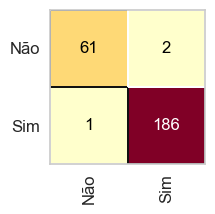

In [258]:
from yellowbrick.classifier import ConfusionMatrix
plt.figure(figsize=(2,2))
cm = ConfusionMatrix(svm_data)
cm.fit(x_data_train, y_data_train)
cm.score(x_data_test, y_data_test)

## Melhor Kernel e C

In [259]:
kernells = ['linear', 'poly', 'rbf','sigmoid']
Cs= [0.1,1,2,10]
best_acc = 0
best_model = None

In [260]:
for i in kernells:
    for j in Cs:
        svm_data = SVC(kernel=i, C=j)
        svm_data.fit(x_data_train, y_data_train)
        previsoes = svm_data.predict(x_data_test)
        accuracy = accuracy_score(y_data_test,previsoes)
        print(f"kennel={i}, C={j}, Accuracy={accuracy}")
        if accuracy > best_acc:
            best_acc = accuracy
            best_model = svm_data

kennel=linear, C=0.1, Accuracy=0.98
kennel=linear, C=1, Accuracy=0.988
kennel=linear, C=2, Accuracy=0.992
kennel=linear, C=10, Accuracy=0.996
kennel=poly, C=0.1, Accuracy=0.972
kennel=poly, C=1, Accuracy=0.972
kennel=poly, C=2, Accuracy=0.964
kennel=poly, C=10, Accuracy=0.972
kennel=rbf, C=0.1, Accuracy=0.776
kennel=rbf, C=1, Accuracy=0.964
kennel=rbf, C=2, Accuracy=0.98
kennel=rbf, C=10, Accuracy=0.964
kennel=sigmoid, C=0.1, Accuracy=0.744
kennel=sigmoid, C=1, Accuracy=0.692
kennel=sigmoid, C=2, Accuracy=0.68
kennel=sigmoid, C=10, Accuracy=0.664


In [261]:

def prever():
    time = int(input("Tempo de Conversa:"))
    laugh = input("Risadas:")
    common_points = int(input("Pontos em Comum:"))
    shyness = int(input("Nível de Timidez:"))
    msg = int(input("Mensagens antes do Encontro:"))
    iniciativa = int(input("Iniciativa:"))
    local = input("Local:")
    moment = input("Momento da Vida:")

prever()

In [262]:
resposta = pd.DataFrame(
    [[time, laugh, common_points, shyness, msg, iniciativa, local, moment]],
    columns=[
        'tempo_conversa_min',
        'risadas',
        'pontos_comuns',
        'nivel_timidez',
        'mensagens_antes',
        'iniciativa_conversa',
        'local_encontro',
        'momento_da_vida'
    ]
)

 
ohc_resposta = column_transformer.transform(resposta)

ohc_resposta = scaler_data.fit_transform(ohc_resposta)
 
datedois = best_model.predict(ohc_resposta)[0]

print(f"Vai dar namoro? {datedois}")
 

NameError: name 'time' is not defined